# Testing on up to 5 lines

This notebook trains a CNN to convert a 64×64 black-and-white raster image containing up to 5 lines vector coordinates.

It uses two stages:

1. **Coordinate pre-training**: the CNN first learns coordinates directly.
2. **Differentiable raster backpropagation**: the predicted vector is rasterised inside TensorFlow, then compared against the original raster image.

# Key Changes

* Image is now 64x64 to reduce over-fitting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from PIL import Image, ImageDraw

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Settings

Image size decreased so that training is faster and there are less variables.

In [2]:
IMG_SIZE = 64

N_TRAIN = 30000
N_TEST = 6000

VECTOR_EPOCHS = 50
RASTER_EPOCHS = 100

BATCH_SIZE = 32

np.random.seed(42)
tf.random.set_seed(42)

## Create synthetic training data

Each sample contains one black line on a white background.

The label is the vector form:

```text
[x1, y1, x2, y2]
```

All coordinates are normalised between 0 and 1.

This part was modified to give more probable lines, it's more likely that engineering drawings have lines on set angles. These weightings can be adjusted later.
This may also be useful if scanning images with impectly straight lines.

In [3]:
MAX_LINES = 5
MIN_LINES = 1
CONFIDENCE_THRESHOLD = 0.5

VALUES_PER_LINE = 5


ANGLE_WEIGHT_90 = 40
ANGLE_WEIGHT_45 = 25
ANGLE_WEIGHT_60 = 15
ANGLE_WEIGHT_30 = 10
ANGLE_WEIGHT_5 = 7
ANGLE_WEIGHT_OTHER = 3

LINE_WIDTH = 1


def build_angle_groups():
    all_angles = set(range(0, 180))

    angle_90 = {angle for angle in all_angles if angle % 90 == 0}

    angle_45 = {
        angle for angle in all_angles
        if angle % 45 == 0 and angle not in angle_90
    }

    angle_60 = {
        angle for angle in all_angles
        if angle % 60 == 0
        and angle not in angle_90
        and angle not in angle_45
    }

    angle_30 = {
        angle for angle in all_angles
        if angle % 30 == 0
        and angle not in angle_90
        and angle not in angle_45
        and angle not in angle_60
    }

    angle_5 = {
        angle for angle in all_angles
        if angle % 5 == 0
        and angle not in angle_90
        and angle not in angle_45
        and angle not in angle_60
        and angle not in angle_30
    }

    used_angles = angle_90 | angle_45 | angle_60 | angle_30 | angle_5
    angle_other = all_angles - used_angles

    return {
        "90": sorted(angle_90),
        "45": sorted(angle_45),
        "60": sorted(angle_60),
        "30": sorted(angle_30),
        "5": sorted(angle_5),
        "other": sorted(angle_other),
    }


ANGLE_GROUPS = build_angle_groups()


def choose_weighted_angle():
    """
    This controls the synthetic data distribution only.
    The model does not manually receive these weights.
    It learns the angle pattern from the examples.
    """

    group_names = ["90", "45", "60", "30", "5", "other"]

    group_weights = np.array([
        ANGLE_WEIGHT_90,
        ANGLE_WEIGHT_45,
        ANGLE_WEIGHT_60,
        ANGLE_WEIGHT_30,
        ANGLE_WEIGHT_5,
        ANGLE_WEIGHT_OTHER
    ], dtype="float32")

    group_probabilities = group_weights / np.sum(group_weights)

    selected_group = np.random.choice(group_names, p=group_probabilities)
    selected_angle = np.random.choice(ANGLE_GROUPS[selected_group])

    return selected_angle


def create_line_image(img_size=32, min_length=12, min_lines=1, max_lines=5):
    """
    Create one image containing between min_lines and max_lines random black lines.

    Label per line:
        centre_x, centre_y, length, confidence, one-hot angle

    The model will later learn to predict one of 180 angle classes.
    """

    max_pixel_length = np.sqrt(2) * (img_size - 1)

    def random_line():
        while True:
            angle_degrees = choose_weighted_angle()
            angle_radians = np.deg2rad(angle_degrees)

            cos_a = np.cos(angle_radians)
            sin_a = np.sin(angle_radians)

            max_length_x = np.inf if abs(cos_a) < 1e-8 else (img_size - 1) / abs(cos_a)
            max_length_y = np.inf if abs(sin_a) < 1e-8 else (img_size - 1) / abs(sin_a)

            max_possible_length = min(max_length_x, max_length_y)

            if max_possible_length < min_length:
                continue

            line_length = np.random.uniform(min_length, max_possible_length)

            dx = cos_a * line_length / 2
            dy = sin_a * line_length / 2

            cx_min = abs(dx)
            cx_max = (img_size - 1) - abs(dx)

            cy_min = abs(dy)
            cy_max = (img_size - 1) - abs(dy)

            if cx_min > cx_max or cy_min > cy_max:
                continue

            cx = np.random.uniform(cx_min, cx_max)
            cy = np.random.uniform(cy_min, cy_max)

            x1 = int(round(cx - dx))
            y1 = int(round(cy - dy))
            x2 = int(round(cx + dx))
            y2 = int(round(cy + dy))

            if not (0 <= x1 < img_size and 0 <= y1 < img_size):
                continue

            if not (0 <= x2 < img_size and 0 <= y2 < img_size):
                continue

            actual_length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

            if actual_length >= min_length:
                cx_actual = (x1 + x2) / 2
                cy_actual = (y1 + y2) / 2

                return x1, y1, x2, y2, cx_actual, cy_actual, actual_length, angle_degrees

    number_of_lines = np.random.randint(min_lines, max_lines + 1)

    lines = []

    for _ in range(number_of_lines):
        lines.append(random_line())

    lines = sorted(
        lines,
        key=lambda line: (
            line[4],
            line[5]
        )
    )

    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)

    label_values = []

    for line in lines:
        x1, y1, x2, y2, cx, cy, length, angle_degrees = line

        draw.line((x1, y1, x2, y2), fill=0, width=LINE_WIDTH)

        angle_one_hot = np.zeros(ANGLE_CLASSES, dtype="float32")
        angle_one_hot[angle_degrees] = 1.0

        label_values.extend([
            cx / (img_size - 1),
            cy / (img_size - 1),
            length / max_pixel_length,
            1.0
        ])

        label_values.extend(angle_one_hot)

    while len(label_values) < max_lines * VALUES_PER_LINE:
        label_values.extend([0.0, 0.0, 0.0, 0.0])
        label_values.extend(np.zeros(ANGLE_CLASSES, dtype="float32"))

    image_array = np.array(image).astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=-1)

    label = np.array(label_values, dtype="float32")

    return image_array, label


def create_dataset(n_samples, img_size=64):
    images = []
    labels = []

    for _ in range(n_samples):
        image, label = create_line_image(
            img_size=img_size,
            min_lines=MIN_LINES,
            max_lines=MAX_LINES
        )

        images.append(image)
        labels.append(label)

    return np.array(images), np.array(labels)

In [4]:
X_train, y_train = create_dataset(N_TRAIN, IMG_SIZE)
X_test, y_test = create_dataset(N_TEST, IMG_SIZE)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (30000, 64, 64, 1)
y_train: (30000, 920)
X_test: (6000, 64, 64, 1)
y_test: (6000, 920)


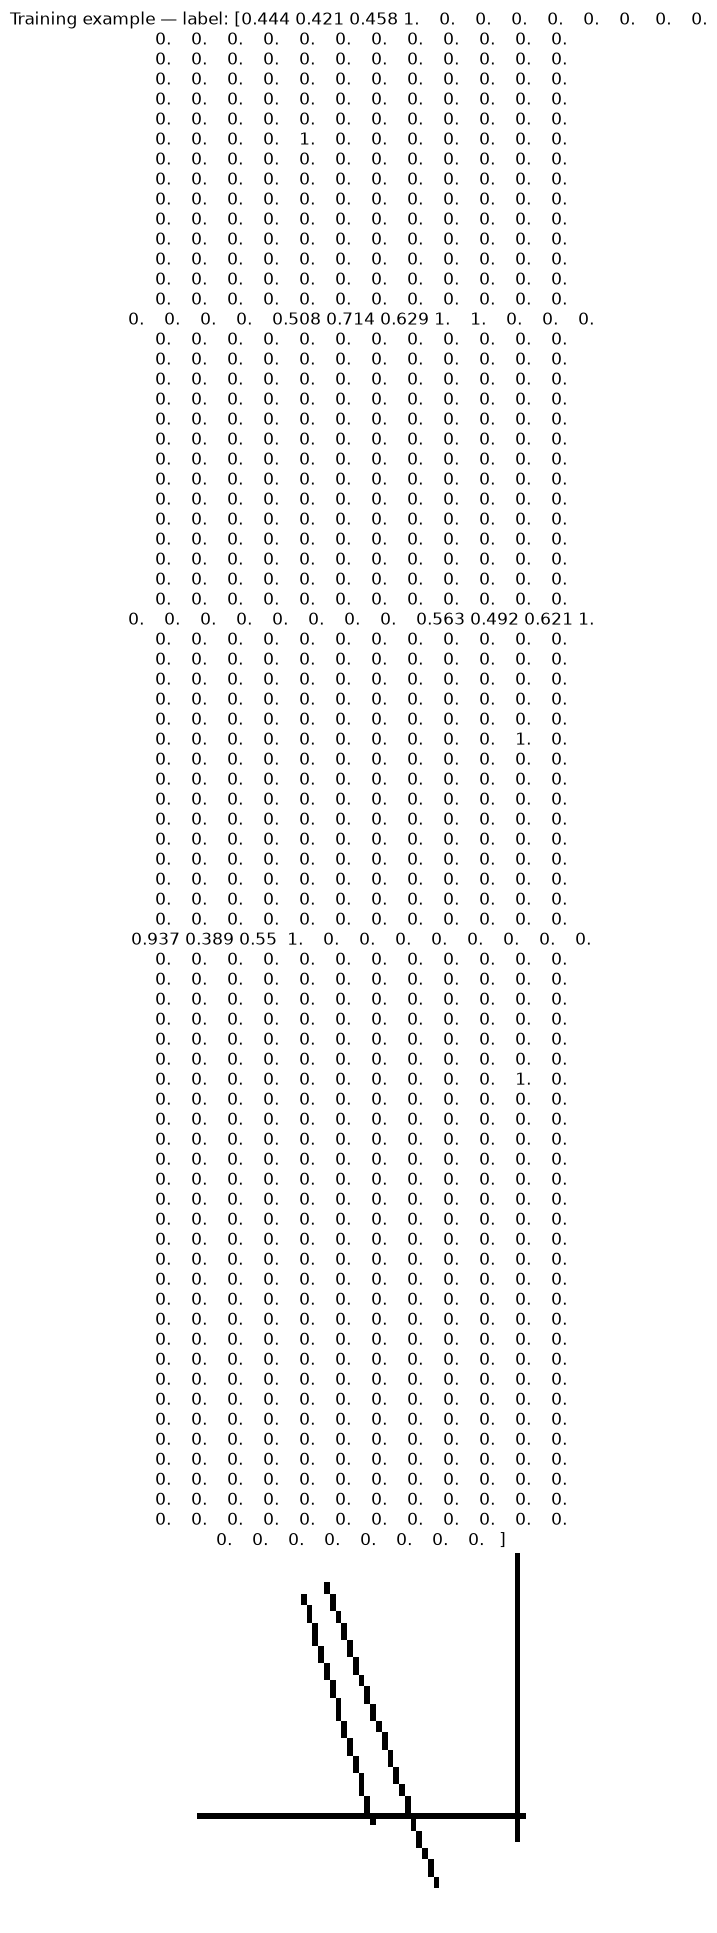

In [5]:
index = 0

plt.imshow(X_train[index].squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title(f"Training example — label: {np.round(y_train[index], 3)}")
plt.axis("off")
plt.show()

## Build the CNN vector model

The CNN predicts four numbers:

```text
[x1, y1, x2, y2]
```

In [6]:
def build_vector_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="raster_input")

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.Flatten()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)

    vector_output = layers.Dense(MAX_LINES * VALUES_PER_LINE, activation=None, name="vector_output")(x)

    return models.Model(inputs=inputs, outputs=vector_output, name="vector_model")


vector_model = build_vector_model()
vector_model.summary()

Model: "vector_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ raster_input (InputLayer)            │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vector_output (Dense)                │ (None, 920)                 │         118,680 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,489,240 (9.50 MB)

 Trainable params: 2,489,240 (9.50 MB)

 Non-trainable params: 0 (0.00 B)

## Coordinate loss

A line is the same line if its endpoints are swapped, so this loss checks both endpoint orders and uses whichever is better.

In [7]:
def line_coordinate_loss(y_true, y_pred):
    """
    Loss for up to MAX_LINES.

    Each predicted line contains:
        centre_x, centre_y, length, confidence, angle logits

    The angle is learned as a 180-class classification problem.
    The model is not manually told which angle groups are important.
    """

    y_true = tf.reshape(y_true, (-1, MAX_LINES, VALUES_PER_LINE))
    y_pred = tf.reshape(y_pred, (-1, MAX_LINES, VALUES_PER_LINE))

    true_cxcy_length = y_true[:, :, 0:3]
    true_conf = y_true[:, :, 3]
    true_angle_one_hot = y_true[:, :, 4:]

    pred_cxcy_length = tf.sigmoid(y_pred[:, :, 0:3])
    pred_conf = tf.sigmoid(y_pred[:, :, 3])
    pred_angle_logits = y_pred[:, :, 4:]

    geometry_loss = tf.reduce_mean(
        tf.square(true_cxcy_length - pred_cxcy_length),
        axis=-1
    )

    geometry_loss = geometry_loss * true_conf

    angle_loss = tf.keras.losses.categorical_crossentropy(
        true_angle_one_hot,
        pred_angle_logits,
        from_logits=True
    )

    angle_loss = angle_loss * true_conf

    confidence_loss = tf.keras.backend.binary_crossentropy(
        true_conf,
        pred_conf
    )

    real_line_count = tf.reduce_sum(true_conf, axis=1) + 1e-8

    geometry_loss = tf.reduce_sum(geometry_loss, axis=1) / real_line_count
    angle_loss = tf.reduce_sum(angle_loss, axis=1) / real_line_count
    confidence_loss = tf.reduce_mean(confidence_loss, axis=1)

    total_loss = geometry_loss + angle_loss + confidence_loss

    return tf.reduce_mean(total_loss)

## Stage 1 — train the CNN on vector coordinates first

This prevents the raster model from collapsing into a fuzzy dot.

In [8]:
vector_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=line_coordinate_loss,
    metrics=["mae"]
)

# early stop if over-fitting

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_vector = vector_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=VECTOR_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - loss: 2.2378 - mae: 5.2534 - val_loss: 1.5537 - val_mae: 6.6397
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - loss: 1.3246 - mae: 7.8425 - val_loss: 1.2532 - val_mae: 8.8660
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - loss: 1.0839 - mae: 10.5255 - val_loss: 1.1583 - val_mae: 11.8255
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - loss: 0.9423 - mae: 13.5669 - val_loss: 1.1337 - val_mae: 14.7604
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - loss: 0.8461 - mae: 16.8459 - val_loss: 1.1721 - val_mae: 18.0218
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - loss: 0.7688 - mae: 20.1137 - val_loss: 1.1649 - val_mae: 21.3364
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - loss: 0.6960 - mae: 23.9243 - val_loss: 1.2633 - val_mae: 24.4912


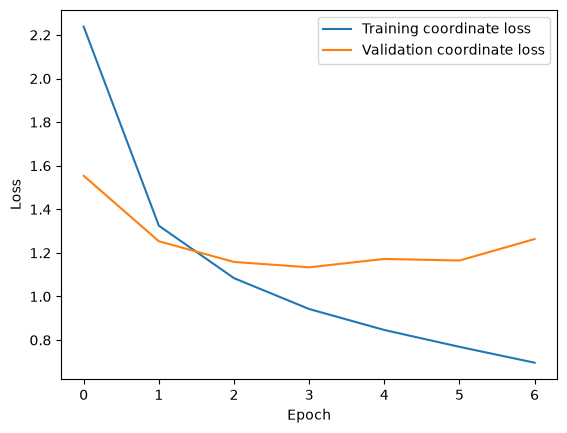

In [9]:
plt.plot(history_vector.history["loss"], label="Training coordinate loss")
plt.plot(history_vector.history["val_loss"], label="Validation coordinate loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Differentiable rasteriser

This layer converts predicted vector coordinates back into a soft raster image using TensorFlow maths.

Because it is TensorFlow-based, backpropagation can pass through it.

In [10]:
class DifferentiableLineRasteriser(layers.Layer):
    def __init__(self, img_size=64, sigma=0.018, **kwargs):
        super().__init__(**kwargs)
        self.img_size = img_size
        self.sigma = sigma

        xs = tf.linspace(0.0, 1.0, img_size)
        ys = tf.linspace(0.0, 1.0, img_size)

        grid_x, grid_y = tf.meshgrid(xs, ys)

        self.grid_x = tf.reshape(grid_x, (1, 1, img_size, img_size))
        self.grid_y = tf.reshape(grid_y, (1, 1, img_size, img_size))

        angle_degrees = tf.range(0, ANGLE_CLASSES, dtype=tf.float32)
        angle_radians = angle_degrees * np.pi / 180.0

        self.angle_cos = tf.reshape(tf.cos(angle_radians), (1, 1, ANGLE_CLASSES))
        self.angle_sin = tf.reshape(tf.sin(angle_radians), (1, 1, ANGLE_CLASSES))

    def call(self, vectors):
        vectors = tf.reshape(vectors, (-1, MAX_LINES, VALUES_PER_LINE))

        pred_cx = tf.sigmoid(vectors[:, :, 0])
        pred_cy = tf.sigmoid(vectors[:, :, 1])
        pred_length = tf.sigmoid(vectors[:, :, 2])
        pred_confidence = tf.sigmoid(vectors[:, :, 3])

        pred_angle_logits = vectors[:, :, 4:]
        pred_angle_probs = tf.nn.softmax(pred_angle_logits, axis=-1)

        # During training this is soft and differentiable.
        # At final prediction we will use argmax to get an exact integer-degree angle.
        cos_a = tf.reduce_sum(pred_angle_probs * self.angle_cos, axis=-1)
        sin_a = tf.reduce_sum(pred_angle_probs * self.angle_sin, axis=-1)

        length = pred_length * np.sqrt(2.0)

        x1 = pred_cx - cos_a * length / 2.0
        y1 = pred_cy - sin_a * length / 2.0
        x2 = pred_cx + cos_a * length / 2.0
        y2 = pred_cy + sin_a * length / 2.0

        x1 = tf.reshape(x1, (-1, MAX_LINES, 1, 1))
        y1 = tf.reshape(y1, (-1, MAX_LINES, 1, 1))
        x2 = tf.reshape(x2, (-1, MAX_LINES, 1, 1))
        y2 = tf.reshape(y2, (-1, MAX_LINES, 1, 1))

        confidence = tf.reshape(pred_confidence, (-1, MAX_LINES, 1, 1))

        px = self.grid_x
        py = self.grid_y

        dx = x2 - x1
        dy = y2 - y1

        length_squared = dx * dx + dy * dy + 1e-8

        t = ((px - x1) * dx + (py - y1) * dy) / length_squared
        t = tf.clip_by_value(t, 0.0, 1.0)

        closest_x = x1 + t * dx
        closest_y = y1 + t * dy

        distance_squared = tf.square(px - closest_x) + tf.square(py - closest_y)

        line_darkness = tf.exp(
            -distance_squared / (2.0 * self.sigma * self.sigma)
        )

        line_darkness = line_darkness * confidence

        combined_darkness = 1.0 - tf.reduce_prod(
            1.0 - line_darkness,
            axis=1
        )

        raster = 1.0 - combined_darkness
        raster = tf.expand_dims(raster, axis=-1)

        return raster

## Weighted raster loss

Normal MSE performs badly because most pixels are white. This weighted loss gives black line pixels much more importance.

In [11]:
def weighted_raster_loss(y_true, y_pred):
    black_pixel_weight = 40.0
    weights = 1.0 + black_pixel_weight * (1.0 - y_true)
    loss = weights * tf.square(y_true - y_pred)
    return tf.reduce_mean(loss)

## Stage 2 — train through the differentiable rasteriser

This model has two losses:

1. Raster loss: predicted raster should match the input raster.
2. Coordinate loss: predicted vector should not drift away from the true vector.

The raster loss is the important Option B part.

In [12]:
raster_output = DifferentiableLineRasteriser(
    img_size=IMG_SIZE,
    sigma=0.010,
    name="raster_output"
)(vector_model.output)

training_model = models.Model(
    inputs=vector_model.input,
    outputs=[raster_output, vector_model.output],
    name="option_b_training_model"
)

training_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=[weighted_raster_loss, line_coordinate_loss],
    loss_weights=[1.0, 0.2],
    metrics=[["mae"], ["mae"]]
)

early_stop_raster = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_raster = training_model.fit(
    X_train,
    [X_train, y_train],
    validation_data=(X_test, [X_test, y_test]),
    epochs=RASTER_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_raster],
    verbose=1
)


Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - loss: 1.1119 - raster_output_loss: 0.9411 - raster_output_mae: 0.0811 - vector_output_loss: 0.8534 - vector_output_mae: 14.8184 - val_loss: 1.1588 - val_raster_output_loss: 0.9322 - val_raster_output_mae: 0.0843 - val_vector_output_loss: 1.1317 - val_vector_output_mae: 14.8191
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - loss: 1.0904 - raster_output_loss: 0.9202 - raster_output_mae: 0.0838 - vector_output_loss: 0.8503 - vector_output_mae: 14.6483 - val_loss: 1.1430 - val_raster_output_loss: 0.9187 - val_raster_output_mae: 0.0837 - val_vector_output_loss: 1.1212 - val_vector_output_mae: 14.7483
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - loss: 1.0766 - raster_output_loss: 0.9064 - raster_output_mae: 0.0839 - vector_output_loss: 0.8503 - vector_output_mae: 14.6455 - val_loss: 1.1309 - val_raster_output_loss: 0.9056 - val_raster_output_mae: 0.0835 - val_vector_output_loss: 1.1253 - val_vector_output_mae: 14

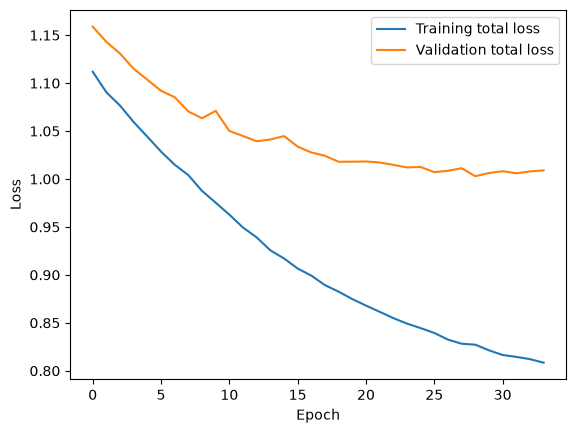

In [13]:
plt.plot(history_raster.history["loss"], label="Training total loss")
plt.plot(history_raster.history["val_loss"], label="Validation total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Test the trained model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
Predicted lines:
Line 1: (39, 6) to (0, 48), angle=135°, confidence=1.00
Line 2: (46, 2) to (0, 57), angle=135°, confidence=1.00
Line 3: (0, 31) to (63, 31), angle=0°, confidence=1.00
Line 4: (0, 29) to (63, 29), angle=0°, confidence=0.96


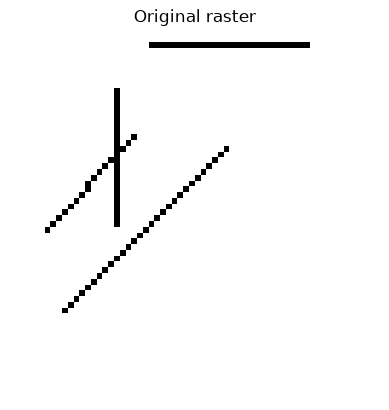

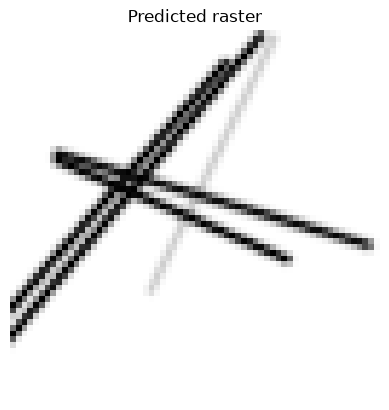

In [14]:
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))


def decode_prediction(prediction, img_size=64, confidence_threshold=0.5):
    prediction = prediction.reshape(MAX_LINES, VALUES_PER_LINE)

    decoded_lines = []

    for line in prediction:
        cx = sigmoid_np(line[0])
        cy = sigmoid_np(line[1])
        length_norm = sigmoid_np(line[2])
        confidence = sigmoid_np(line[3])

        angle_logits = line[4:]
        angle_degrees = int(np.argmax(angle_logits))

        if confidence >= confidence_threshold:
            length = length_norm * np.sqrt(2.0) * (img_size - 1)

            angle_radians = np.deg2rad(angle_degrees)

            dx = np.cos(angle_radians) * length / 2
            dy = np.sin(angle_radians) * length / 2

            cx_pixels = cx * (img_size - 1)
            cy_pixels = cy * (img_size - 1)

            x1 = int(round(cx_pixels - dx))
            y1 = int(round(cy_pixels - dy))
            x2 = int(round(cx_pixels + dx))
            y2 = int(round(cy_pixels + dy))

            x1 = np.clip(x1, 0, img_size - 1)
            y1 = np.clip(y1, 0, img_size - 1)
            x2 = np.clip(x2, 0, img_size - 1)
            y2 = np.clip(y2, 0, img_size - 1)

            decoded_lines.append({
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "angle": angle_degrees,
                "confidence": confidence
            })

    return decoded_lines


sample = X_test[0:1]

predicted_vector = vector_model.predict(sample)[0]
predicted_raster = training_model.predict(sample)[0]

decoded_lines = decode_prediction(
    predicted_vector,
    img_size=IMG_SIZE,
    confidence_threshold=CONFIDENCE_THRESHOLD
)

print("Predicted lines:")

for i, line in enumerate(decoded_lines):
    print(
        f"Line {i + 1}: "
        f"({line['x1']}, {line['y1']}) to ({line['x2']}, {line['y2']}), "
        f"angle={line['angle']}°, "
        f"confidence={line['confidence']:.2f}"
    )

plt.imshow(sample.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Original raster")
plt.axis("off")
plt.show()

plt.imshow(predicted_raster.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Predicted raster")
plt.axis("off")
plt.show()

## Compare several predictions

Example 0
True pixels:      [14 26 16 63  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 63  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 18 22 16 63  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 63  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  

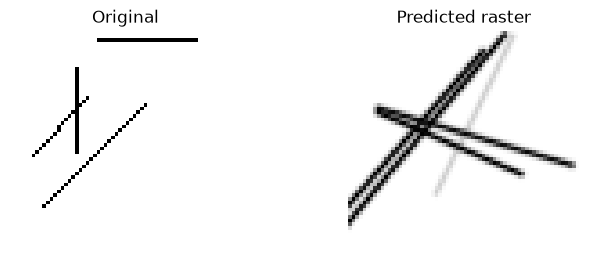

Example 1
True pixels:      [14 48 27 63  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0 63  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 30 30 49 63  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  

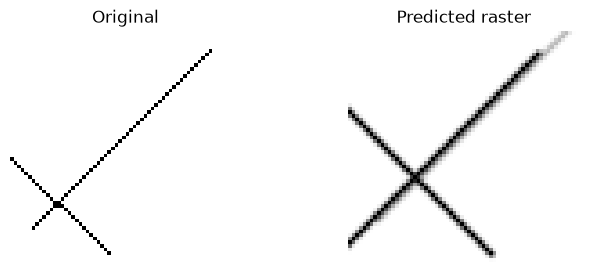

Example 2
True pixels:      [18 32 27 63  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 63  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 25 48 16 63  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 63  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  

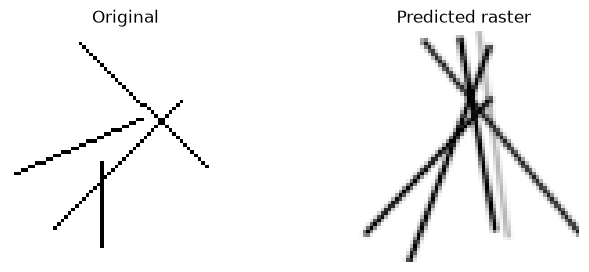

Example 3
True pixels:      [42 40 33 63  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 63  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 42 50 24 63  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  

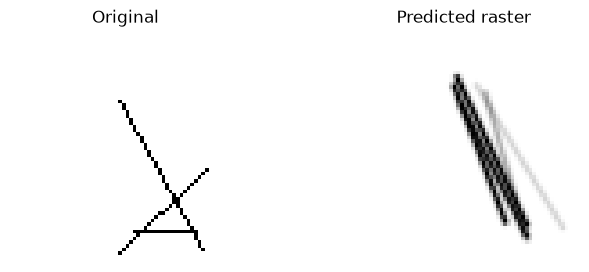

Example 4
True pixels:      [34 20 36 63  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0 63  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 39 24 28 63  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 63  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  

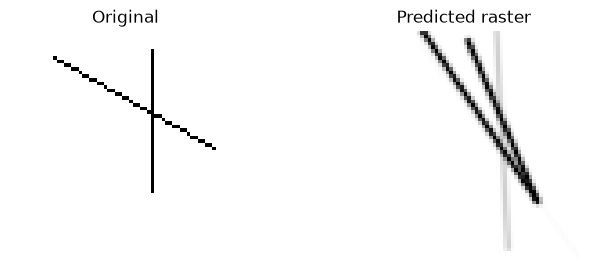

In [15]:
for sample_index in range(5):
    sample = X_test[sample_index:sample_index + 1]
    true_vector = y_test[sample_index]
    predicted_vector = vector_model.predict(sample, verbose=0)[0]
    predicted_raster = training_model.predict(sample, verbose=0)[0]

    print("Example", sample_index)
    print("True pixels:     ", np.round(true_vector * (IMG_SIZE - 1)).astype(int))
    print("Predicted pixels:", np.round(predicted_vector * (IMG_SIZE - 1)).astype(int))

    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(sample.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_raster.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title("Predicted raster")
    plt.axis("off")

    plt.show()